In [8]:
# Standard library
import numpy as np
import matplotlib.pyplot as plt

# RFModel core
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.config import load_yaml

# Comms
from rfmodel.comms.pseudorandom_NGR import PRBSBitSource, PRBSParams
from rfmodel.comms.QAM_modulator import QAMModulator, QAMParams
from rfmodel.comms.OFDM_block import OFDMModulator, OFDMParams
from rfmodel.plot_utils.plot_block_diagram import plot_pipeline

# Plot utilities
from rfmodel.plot_utils import (
    plot_bits,
    plot_constellation,
    plot_constellation_with_bits,
    plot_ofdm_frequency_bins_centered,
    plot_time_signal,
    plot_spectrum,
    reconstruct_one_ofdm_symbol_freq,
)

# Registries
import rfmodel.rf.registry
import rfmodel.channel.registry

# Input Generation

Number of bits: 19968
Expected QAM symbols: 3328
Bits per symbol: 6
{'name': 'PRBS15 Input Bits', 'source': 'PRBS15', 'prbs_order': 15, 'n_bits': 19968, 'seed': 123}


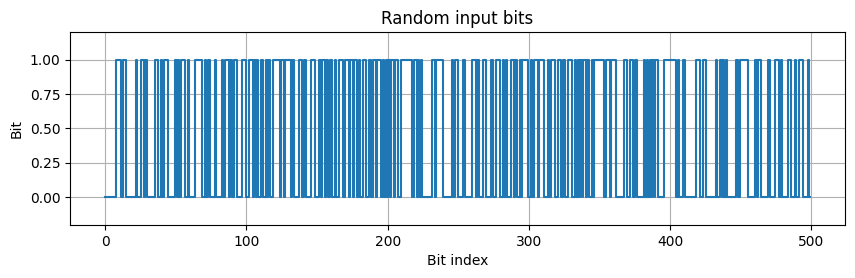

In [9]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
M = 64 #QAM modulation
bits_per_symbol = int(np.log2(M)) # 6 Bits for 64-QAM

fs_hz = 20e6 # Channel Bandwidth
n_fft = 64   # FFT Size
cp_len = 16  # Cyclic Prefix Length
n_data_subcarriers = 52 # Number of true data subcarriers
num_ofdm_symbols = 64   # Number of Symbols

n_qam_symbols_transmitted = num_ofdm_symbols * n_data_subcarriers # Actual Transmitted QAM Symbols

# --------------------------------------------------
# Generate bits (Pseudo Random)
# --------------------------------------------------
dummy_sig = Signal(x=np.array([], dtype=np.uint8), fs_hz=fs_hz, meta={"name": "PRBS15 Input Bits"})

prbs_gen = PRBSBitSource(
    name="tx_bits",
    params=PRBSParams(
        order=15,
        n_bits=n_qam_symbols_transmitted * bits_per_symbol,
        seed=123,
    ),
)

sig_bits = prbs_gen.process(dummy_sig)
bits = sig_bits.x

print("Number of bits:", len(bits))
print("Expected QAM symbols:", n_qam_symbols_transmitted)
print("Bits per symbol:", bits_per_symbol)
print(sig_bits.meta)
plot_bits(bits, n_bits=500, title="Random input bits")


# Allocate symbols to QAM and OFDM

In [10]:
# --------------------------------------------------
# QAM modulation
# --------------------------------------------------
qam = QAMModulator(
    "qam1",
    QAMParams(
        M=M,
        gray_map=False,
        unit_average_power=True,
    )
)

sig_qam = qam.process(sig_bits)
qam_symbols = sig_qam.x

# --------------------------------------------------
# OFDM modulation
# --------------------------------------------------
ofdm = OFDMModulator(
    "ofdm1",
    OFDMParams(
        n_fft=n_fft,
        cp_len=cp_len,
        n_data_subcarriers=n_data_subcarriers,
        normalize_ifft=True,
        null_dc=True,
    )
)

sig_ofdm = ofdm.process(sig_qam)
tx_input = sig_ofdm.x

print("OFDM output samples:", len(tx_input))
print("Expected samples:", num_ofdm_symbols * (n_fft + cp_len))

OFDM output samples: 5120
Expected samples: 5120


Target Power: -50.0 dBm
Actual Scaled Power: -50.88 dBm


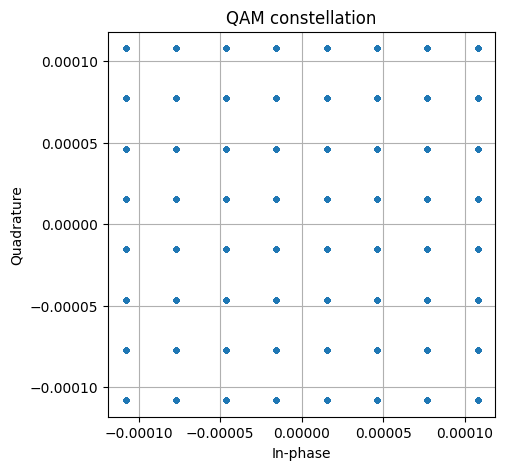

In [16]:
from rfmodel.core.units import dbm_to_w

# Define your target input power to the LNA/Pipeline
input_pwr_dbm = -50.0  # Common LNA input level
p_watts = dbm_to_w(input_pwr_dbm)


scaling_factor = np.sqrt(p_watts)
sig_ofdm_normalized = sig_ofdm.copy_with(x= sig_ofdm.x * scaling_factor)

actual_pwr_watts = np.mean(np.abs(sig_ofdm_normalized.x)**2)
actual_pwr_dbm = 10 * np.log10(actual_pwr_watts) + 30

print(f"Target Power: {input_pwr_dbm} dBm")
print(f"Actual Scaled Power: {actual_pwr_dbm:.2f} dBm")
plot_constellation(ofdm.demodulate(sig_ofdm_normalized).x)

# PipeLine Initiation

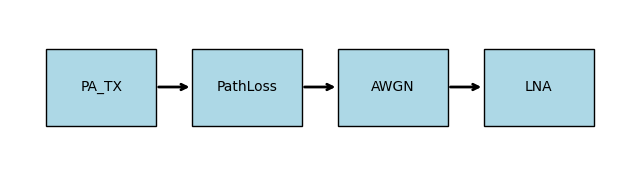

Input Peak:    0.000262
Peak after PA_TX   : 0.002617
Peak after PathLoss: 0.000010
Peak after AWGN    : 0.000010
Peak after LNA     : 0.000102


In [ ]:
cfg = load_yaml(r".\Tx_channel_Rx.yaml")
pipe = pipeline_from_config(cfg)
plot_pipeline(pipe)

output_sig, taps = pipe.run(sig_ofdm_normalized, taps=["PA_TX", "PathLoss", "AWGN", "LNA"])

print(f"Input Peak:    {np.max(np.abs(sig_ofdm_normalized.x)):.6f}")

for block_name, signal in taps.items():
    peak = np.max(np.abs(signal.x))
    print(f"Peak after {block_name:8}: {peak:.6f}")

# Transmission Through PipeLine

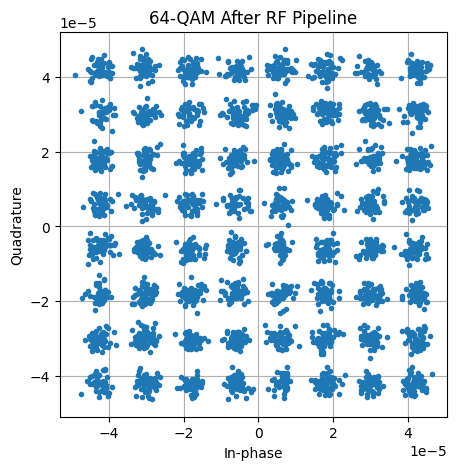

In [ ]:
sig_out, taps = pipe.run(sig_ofdm_normalized, taps=["PA_TX"])
# Demodulate the OFDM signal
sig_demod = ofdm.demodulate(sig_out)

# Plot to see the effect of your RF chain
plot_constellation(sig_demod.x, title="64-QAM After RF Pipeline")